# Perturb-FISH: Explatory Data Analaysis

This notebook shows quick exploratory analysis of a Perturb-FISH dataset. 


## Load packages



In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
#import squidpy as sq
from anndata import AnnData

from scipy import stats
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

from sklearn.neighbors import BallTree

import matplotlib.patches as mpatches

#from utils.single_cell import *
#from scripts.benchmark import plot_causal_volcano 

In [57]:
#base = "/home/edizcan/sds-hd/sd22b002/guest/zeynep_thesis/perturb_fish/tumors"
base = "/data/a330d/projects/cellina-reproducibility/notebooks/in_vivo/data/"

df = pd.read_csv(f"{base}/merfishcounttable.csv", header=None)
cell_idx = df.iloc[:, 0].values
area     = df.iloc[:, 1].values
counts   = df.iloc[:, 3:3+500].values          # first 500 count cols = real genes; drop ~50 blanks

# gene names: prefer the codebook; fallback = tumorMerfish.csv column order
try:
    cb = pd.read_csv(f"{base}/codebook_0_ImmunOncology_0.csv")
    gene_names = cb.iloc[:, 0].astype(str).values[:500]   # adjust col if needed
except FileNotFoundError:
    gene_names = pd.read_csv(f"{base}/tumorMerfish.csv", nrows=0).columns[:500].values

In [58]:
total = counts.sum(1)
keep  = (total > 40) & (total < 800) & (area > 2000) & (area < 30000)   # strict, matches authors

coords = pd.read_csv(f"{base}/coordinates.csv", header=None).values      # check header=None vs 0

adata = AnnData(counts[keep].astype(np.int32))
adata.var_names = gene_names
adata.obs["cell_index"]  = cell_idx[keep]
adata.obs["area"]        = area[keep]
adata.obs["total_counts"] = total[keep]
adata.obsm["spatial"]    = coords[keep, -2:] 

adata

AnnData object with n_obs × n_vars = 153705 × 500
    obs: 'cell_index', 'area', 'total_counts'
    obsm: 'spatial'

In [59]:
ref = sc.read_h5ad(f"{base}/tumors_qc_test.h5ad")   # 154418 × 154, already annotated

# coordinate lookup from the reference (round to kill float noise; drop rare dup coords)
ref_lookup = pd.DataFrame(np.asarray(ref.obsm["spatial"])[:, :2], columns=["x", "y"])
for c in ["celltype", "celltype2", "perturbation", "n_perturb"]:
    if c in ref.obs:
        ref_lookup[c] = ref.obs[c].values
ref_lookup = ref_lookup.round({"x": 3, "y": 3}).drop_duplicates(["x", "y"])

mine = pd.DataFrame(np.asarray(adata.obsm["spatial"])[:, :2], columns=["x", "y"]).round({"x": 3, "y": 3})
merged = mine.merge(ref_lookup, on=["x", "y"], how="left")

for c in ["celltype", "celltype2", "perturbation", "n_perturb"]:
    if c in merged:
        adata.obs[c] = merged[c].values

print("matched:", adata.obs["celltype"].notna().sum(), "/", adata.n_obs)

matched: 9371 / 153705


In [60]:
import numpy as np, pandas as pd

# What does the reference spatial actually look like?
rs = np.asarray(ref.obsm["spatial"])
print("ref spatial:", rs.shape, rs.dtype)
print("ref x range:", rs[:,0].min(), rs[:,0].max())
print("ref y range:", rs[:,1].min(), rs[:,1].max())
print(rs[:5])

# What does your coords file look like?
ms = np.asarray(adata.obsm["spatial"])
print("\nmine spatial:", ms.shape)
print("mine x range:", ms[:,0].min(), ms[:,0].max())
print("mine y range:", ms[:,1].min(), ms[:,1].max())
print(ms[:5])

# Raw coordinates.csv — how many columns, any header?
craw = pd.read_csv(f"{base}/coordinates.csv", header=None, nrows=5)
print("\ncoordinates.csv head:", craw.shape)
print(craw)

# Do the ROW COUNTS line up with anything?
print("\ncoordinates.csv full length:")
print(len(pd.read_csv(f"{base}/coordinates.csv", header=None)))

ref spatial: (154418, 2) float64
ref x range: 63.9312207555065 89393.1968057344
ref y range: 92974.7980258842 153159.954802474
[[7.03205403e+01 1.26665503e+05]
 [7.19550267e+01 1.28280027e+05]
 [1.26485493e+02 1.28631438e+05]
 [9.97899967e+01 1.29238802e+05]
 [1.28678001e+02 1.30309648e+05]]

mine spatial: (153705, 2)
mine x range: 63.9312207555065 89403.7582707895
mine y range: 93086.0898650348 153159.954802474
[[7.19550267e+01 1.28280027e+05]
 [6.39312208e+01 1.30905585e+05]
 [8.56270636e+01 1.32744086e+05]
 [8.01415702e+01 1.34249789e+05]
 [7.68264591e+01 1.34434331e+05]]

coordinates.csv head: (5, 2)
            0              1
0   75.164793  124907.488559
1   52.238455  125139.546426
2   89.813397  125482.203594
3   55.184152  126332.680584
4  112.873177  126514.208587

coordinates.csv full length:
187215


In [61]:
df = pd.read_csv(f"{base}/merfishcounttable.csv", header=None)
coords_all = pd.read_csv(f"{base}/coordinates.csv", header=None).values

print("counttable rows:", len(df), " coords rows:", len(coords_all))   # both 187215?

# The counttable col 3 is a linearized centroid (sub2ind over mask [102389,169973]).
# Decode it and compare to coordinates.csv to see if the two files share row order.
lin = df.iloc[:, 2].values.astype(np.int64)
# MATLAB sub2ind([nrows, ncols], r, c) = r + (c-1)*nrows, with nrows=102389
nrows = 102389
r = ((lin - 1) % nrows) + 1
c = ((lin - 1) // nrows) + 1
print("\ndecoded centroid (r,c) first 5:")
print(np.column_stack([r, c])[:5])
print("coordinates.csv first 5:")
print(coords_all[:5])

counttable rows: 187215  coords rows: 187215

decoded centroid (r,c) first 5:
[[34683   125]
 [28839    87]
 [67789   149]
 [18776    92]
 [97579   187]]
coordinates.csv first 5:
[[7.51647932e+01 1.24907489e+05]
 [5.22384549e+01 1.25139546e+05]
 [8.98133966e+01 1.25482204e+05]
 [5.51841517e+01 1.26332681e+05]
 [1.12873177e+02 1.26514209e+05]]


In [62]:
# Reference annotations keyed by exact coordinate
ref_df = pd.DataFrame(np.asarray(ref.obsm["spatial"])[:, :2], columns=["x", "y"])
for col in ["celltype", "celltype2", "perturbation", "n_perturb"]:
    if col in ref.obs:
        ref_df[col] = ref.obs[col].values

# All-cells coordinates tagged with original row index (== counttable row index)
coords_all = pd.read_csv(f"{base}/coordinates.csv", header=None).values
all_df = pd.DataFrame(coords_all[:, :2], columns=["x", "y"])
all_df["orig_row"] = np.arange(len(all_df))

hit = all_df.merge(ref_df, on=["x", "y"], how="inner").drop_duplicates("orig_row")
print("exact matches:", len(hit), "/", len(ref_df))

exact matches: 154418 / 154418


In [63]:
ref

AnnData object with n_obs × n_vars = 154418 × 154
    obs: 'celltype', 'n_perturb', 'perturbation', 'n_counts', 'celltype2'
    var: 'n_counts'
    uns: 'celltype2_colors', 'log1p', 'pca'
    obsm: 'X_pca', 'spatial'
    varm: 'PCs'

In [64]:
adata

AnnData object with n_obs × n_vars = 153705 × 500
    obs: 'cell_index', 'area', 'total_counts', 'celltype', 'celltype2', 'perturbation', 'n_perturb'
    obsm: 'spatial'

In [65]:
rows = hit["orig_row"].values                      # original counttable/coords rows
counts = df.iloc[rows, 3:3+500].values

adata = AnnData(counts.astype(np.int32))
adata.var_names = gene_names
adata.obs_names = [str(i) for i in rows]
adata.obs["cell_index"]   = df.iloc[rows, 0].values
adata.obs["area"]         = df.iloc[rows, 1].values
adata.obs["total_counts"] = counts.sum(1)
adata.obsm["spatial"]     = coords_all[rows, :2]
for col in ["celltype", "celltype2", "perturbation", "n_perturb"]:
    if col in hit:
        adata.obs[col] = hit[col].values

assert np.allclose(adata.X, np.round(adata.X))
print(adata)
print(adata.obs["celltype"].value_counts(dropna=False))
print(adata.obs["perturbation"].value_counts(dropna=False).head())

AnnData object with n_obs × n_vars = 154418 × 500
    obs: 'cell_index', 'area', 'total_counts', 'celltype', 'celltype2', 'perturbation', 'n_perturb'
    obsm: 'spatial'
celltype
NaN      145047
tumor      9371
Name: count, dtype: int64
perturbation
NaN        145047
Control      4250
IRF3          427
IRAK4         383
IRF5          362
Name: count, dtype: int64


In [66]:
adata

AnnData object with n_obs × n_vars = 154418 × 500
    obs: 'cell_index', 'area', 'total_counts', 'celltype', 'celltype2', 'perturbation', 'n_perturb'
    obsm: 'spatial'

## Load datasets
 

In [ ]:
#adata = sc.read_h5ad("/home/edizcan/sds-hd/sd22b002/guest/zeynep_thesis/perturb_fish/tumors/pfish_xenograf_tumor_linearized.h5ad")
#adata

AnnData object with n_obs × n_vars = 154418 × 154
    obs: 'celltype', 'n_perturb', 'perturbation', 'n_counts', 'celltype2'
    var: 'n_counts'
    uns: 'celltype2_colors', 'log1p', 'pca'
    obsm: 'X_pca', 'spatial'
    varm: 'PCs'
    layers: 'log1p'

In [10]:
adata.obs["n_perturb"].value_counts()

n_perturb
0    145047
1      9064
2       301
3         6
Name: count, dtype: int64

In [11]:
# Check mt genes
adata.var["mt"] = adata.var_names.str.lower().str.startswith("mt-")
print("MT genes found:", int(adata.var["mt"].sum()))

MT genes found: 0


In [25]:
sc.pp.calculate_qc_metrics(
    adata,
    percent_top=None,
    inplace=True
)

adata

AnnData object with n_obs × n_vars = 154418 × 500
    obs: 'cell_index', 'area', 'total_counts', 'celltype', 'celltype2', 'perturbation', 'n_perturb', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'

## Run eda functions

cells: 154,418    genes: 500
     total_counts  n_genes_by_counts
min          40.0                9.0
25%         115.0               63.0
50%         196.0               88.0
75%         318.0              115.0
max         926.0              221.0
------------------------------------------------------------


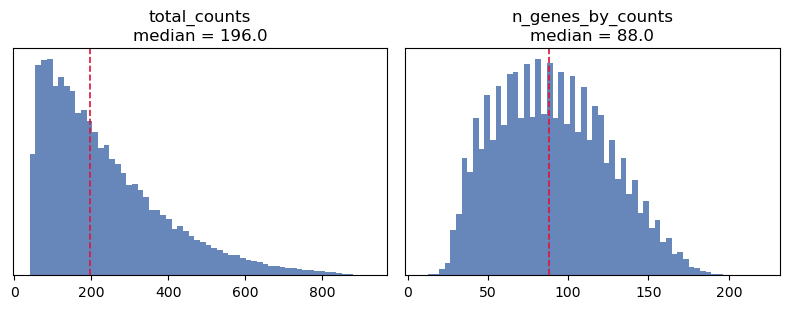

/home/edizcan/SPERB/src/utils/single_cell.py:105: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sca = ax.scatter(


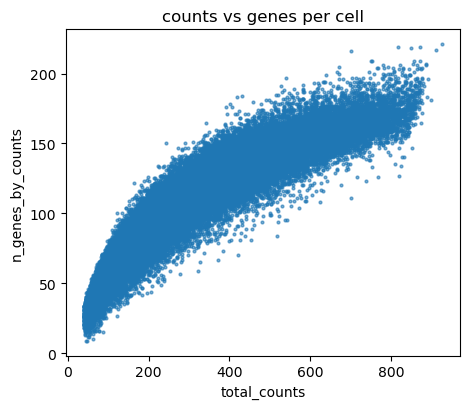

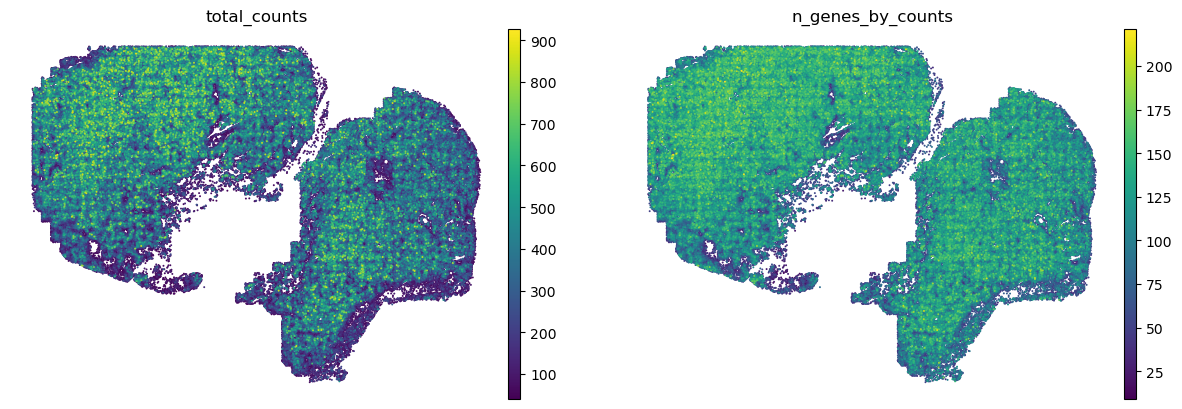

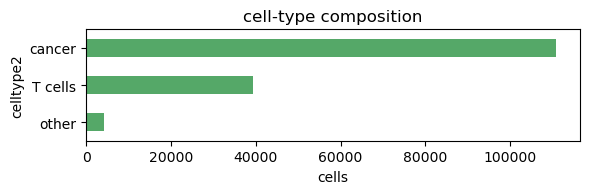

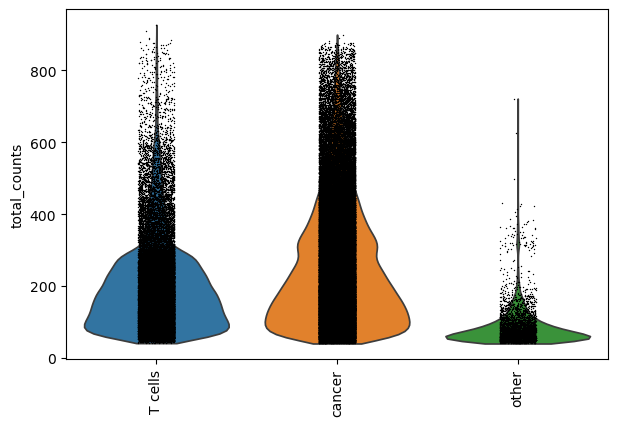

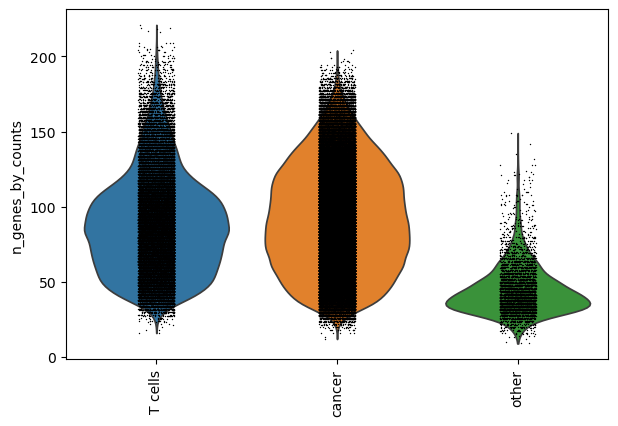

In [16]:
qc_overview(
    adata,
    count_key="total_counts",
    feature_key="n_genes_by_counts",
    mt_key=None,               # no MT genes on this panel
    celltype_key="celltype2",
    spatial_basis="spatial",
)

There is no mitochondrial genes counted on perturb-fish. Also since this dataset has only 154 genes, we cannot do PCA which is mainly useful when we have thousands of genes. 

Perturbation status inferred from 'n_perturb' > 0.
Number of total cell types: 3
Number of selected cell types: 3
Number of plotted status-celltype categories: 6

Cell type perturbation summary:
_perturb_status  control  perturbed   total  fraction_perturbed  \
celltype2                                                         
cancer            103416       7496  110912            0.067585   
T cells            37521       1729   39250            0.044051   
other               4110        146    4256            0.034305   

_perturb_status  fraction_control  
celltype2                          
cancer                   0.932415  
T cells                  0.955949  
other                    0.965695  

Categories with unique colors: 6
Categories assigned black: 0


/home/edizcan/SPERB/src/utils/single_cell.py:238: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([celltype_col, "_perturb_status"])


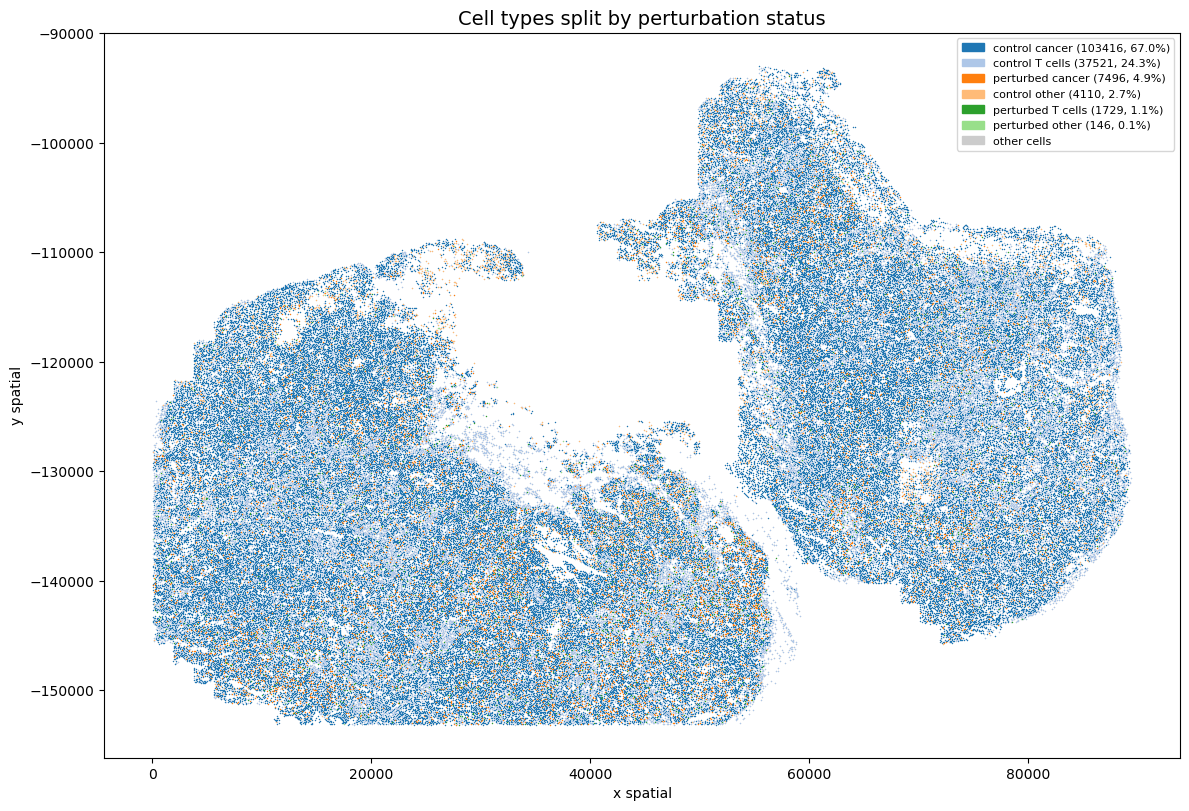

In [17]:
fig, ax, category_summary, celltype_summary, category_color_map = (
    visualize_celltype(
        adata,
        celltype_col="celltype2",
        n_celltypes=3,
        point_size=1.0
    )
)

Number of unique perturbation labels: 157
Number of genes in adata: 500
Number of direct perturbation-gene matches: 11

Selected cell type: cancer
Number of matched perturbation genes in this cell type: 11
Number of perturbation genes selected for plotting: 7
Genes with unique colors: 7
Genes assigned black: 0


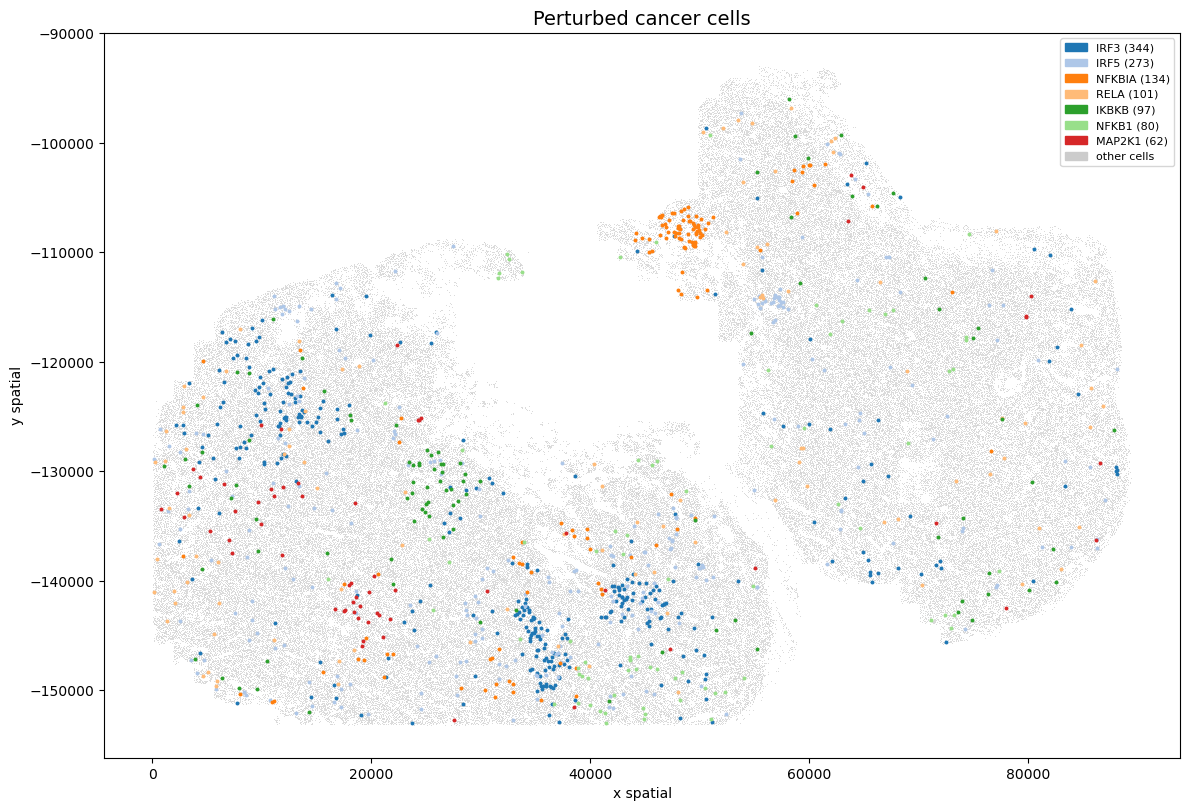

In [18]:
fig, ax, selected_counts, gene_color_map = visualize_perturbation(
    adata,
    cell_type="cancer",
    n_perturbation=7
)

In [22]:
# Now this adata has raw counts adata.X
adata.layers["counts"] = adata.X.copy()
adata.layers["lognorm"] = adata.X.copy()
tmp = sc.AnnData(adata.layers["lognorm"], obs=adata.obs, var=adata.var)
sc.pp.normalize_total(tmp)
sc.pp.log1p(tmp)
adata.layers["lognorm"] = tmp.X
adata

AnnData object with n_obs × n_vars = 154418 × 500
    obs: 'cell_index', 'area', 'total_counts', 'celltype', 'celltype2', 'perturbation', 'n_perturb', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'celltype2_colors'
    obsm: 'spatial'
    layers: 'counts', 'lognorm'

Expression source: adata.layers['lognorm']
Expression scale: lognorm
Cell type: cancer
Gene: CD14
Perturbed cells: 16
Control cells: 3452

Summary:
            group  n_cells      mean  median  fraction_zero  \
0         Control     3452  0.048257     0.0       0.900927   
1  CD14 perturbed       16  0.014173     0.0       0.937500   

   mannwhitneyu_pvalue  
0              0.56895  
1              0.56895  


/home/edizcan/SPERB/src/utils/single_cell.py:743: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


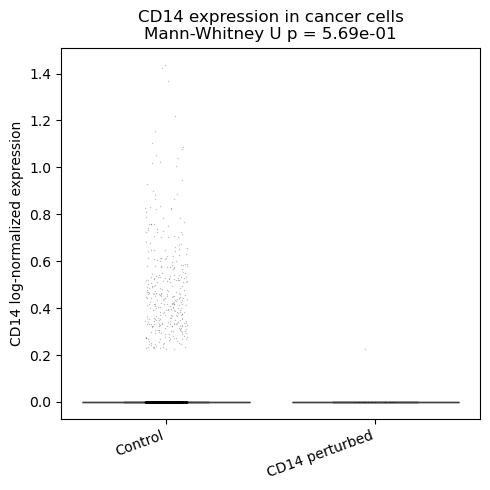

Expression source: adata.layers['lognorm']
Expression scale: lognorm
Cell type: cancer
Gene: IKBKB
Perturbed cells: 97
Control cells: 3452

Summary:
             group  n_cells      mean  median  fraction_zero  \
0          Control     3452  0.170199     0.0       0.696408   
1  IKBKB perturbed       97  0.116367     0.0       0.793814   

   mannwhitneyu_pvalue  
0               0.0355  
1               0.0355  


/home/edizcan/SPERB/src/utils/single_cell.py:743: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


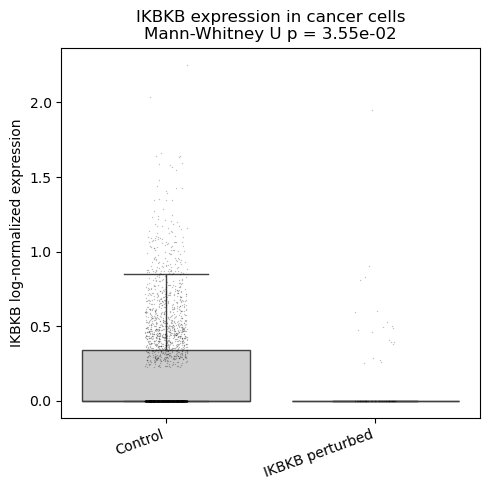

Expression source: adata.layers['lognorm']
Expression scale: lognorm
Cell type: cancer
Gene: IRF3
Perturbed cells: 344
Control cells: 3452

Summary:
            group  n_cells      mean  median  fraction_zero  \
0         Control     3452  0.045738     0.0       0.901506   
1  IRF3 perturbed      344  0.048415     0.0       0.898256   

   mannwhitneyu_pvalue  
0             0.844378  
1             0.844378  


/home/edizcan/SPERB/src/utils/single_cell.py:743: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


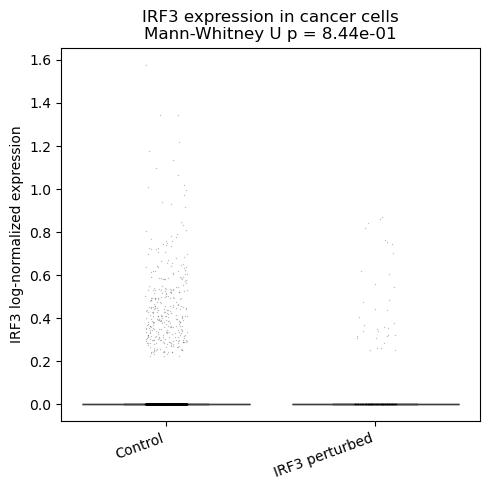

Expression source: adata.layers['lognorm']
Expression scale: lognorm
Cell type: cancer
Gene: IRF5
Perturbed cells: 273
Control cells: 3452

Summary:
            group  n_cells      mean  median  fraction_zero  \
0         Control     3452  0.006021     0.0       0.987254   
1  IRF5 perturbed      273  0.001809     0.0       0.996337   

   mannwhitneyu_pvalue  
0              0.18716  
1              0.18716  


/home/edizcan/SPERB/src/utils/single_cell.py:743: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


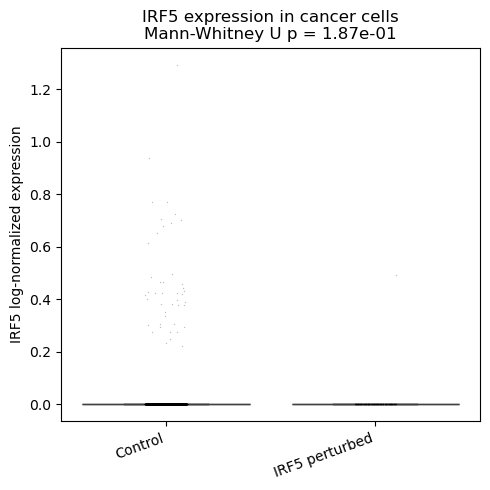

Expression source: adata.layers['lognorm']
Expression scale: lognorm
Cell type: cancer
Gene: JUN
Perturbed cells: 53
Control cells: 3452

Summary:
           group  n_cells      mean    median  fraction_zero  \
0        Control     3452  0.745036  0.742472       0.235226   
1  JUN perturbed       53  1.307951  1.135654       0.113208   

   mannwhitneyu_pvalue  
0             0.000002  
1             0.000002  


/home/edizcan/SPERB/src/utils/single_cell.py:743: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


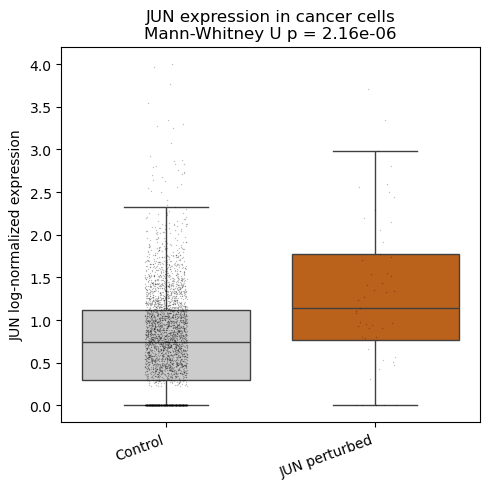

Expression source: adata.layers['lognorm']
Expression scale: lognorm
Cell type: cancer
Gene: MAP2K1
Perturbed cells: 62
Control cells: 3452

Summary:
              group  n_cells      mean  median  fraction_zero  \
0           Control     3452  0.121960     0.0       0.752317   
1  MAP2K1 perturbed       62  0.066934     0.0       0.838710   

   mannwhitneyu_pvalue  
0             0.094671  
1             0.094671  


/home/edizcan/SPERB/src/utils/single_cell.py:743: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


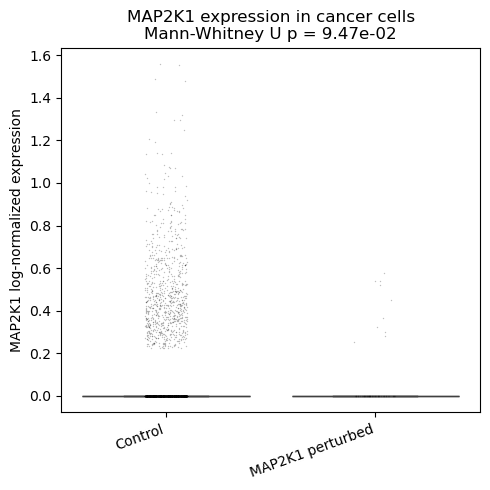

Expression source: adata.layers['lognorm']
Expression scale: lognorm
Cell type: cancer
Gene: NFKB1
Perturbed cells: 80
Control cells: 3452

Summary:
             group  n_cells      mean    median  fraction_zero  \
0          Control     3452  0.574858  0.594207       0.282155   
1  NFKB1 perturbed       80  0.416346  0.382428       0.462500   

   mannwhitneyu_pvalue  
0             0.003203  
1             0.003203  


/home/edizcan/SPERB/src/utils/single_cell.py:743: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


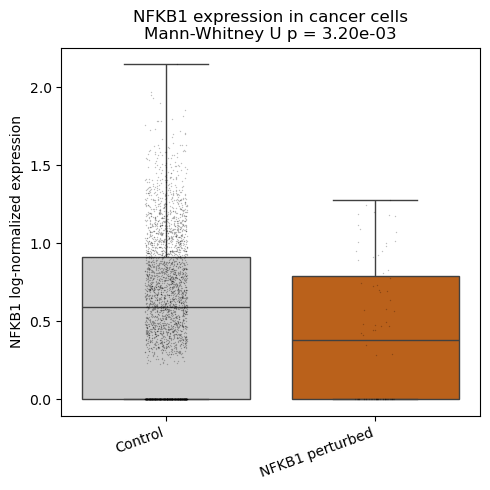

/home/edizcan/SPERB/src/utils/single_cell.py:743: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Expression source: adata.layers['lognorm']
Expression scale: lognorm
Cell type: cancer
Gene: NFKBIA
Perturbed cells: 134
Control cells: 3452

Summary:
              group  n_cells      mean    median  fraction_zero  \
0           Control     3452  0.515506  0.488718       0.354577   
1  NFKBIA perturbed      134  0.312390  0.000000       0.604478   

   mannwhitneyu_pvalue  
0         8.287944e-07  
1         8.287944e-07  


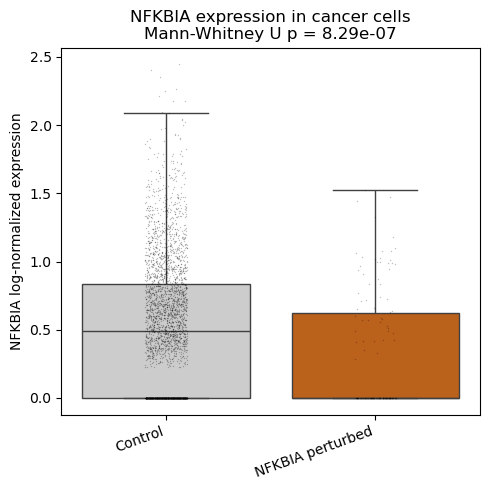

Expression source: adata.layers['lognorm']
Expression scale: lognorm
Cell type: cancer
Gene: PIK3CA
Perturbed cells: 55
Control cells: 3452


/home/edizcan/SPERB/src/utils/single_cell.py:743: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(



Summary:
              group  n_cells      mean  median  fraction_zero  \
0           Control     3452  0.229531     0.0       0.597045   
1  PIK3CA perturbed       55  0.120270     0.0       0.781818   

   mannwhitneyu_pvalue  
0             0.006616  
1             0.006616  


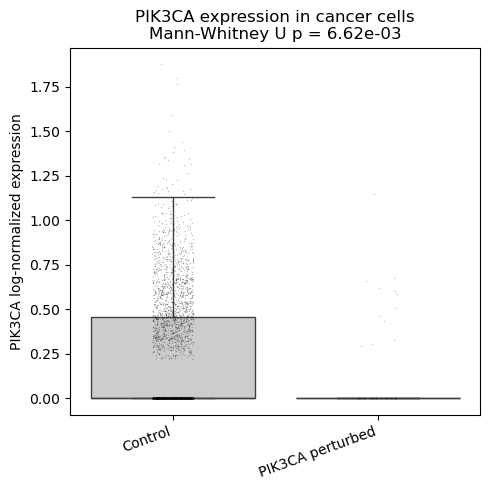

Expression source: adata.layers['lognorm']
Expression scale: lognorm
Cell type: cancer
Gene: RELA
Perturbed cells: 101
Control cells: 3452

Summary:
            group  n_cells      mean    median  fraction_zero  \
0         Control     3452  0.454738  0.461736       0.351390   
1  RELA perturbed      101  0.417902  0.383751       0.445545   

   mannwhitneyu_pvalue  
0             0.327081  
1             0.327081  


/home/edizcan/SPERB/src/utils/single_cell.py:743: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


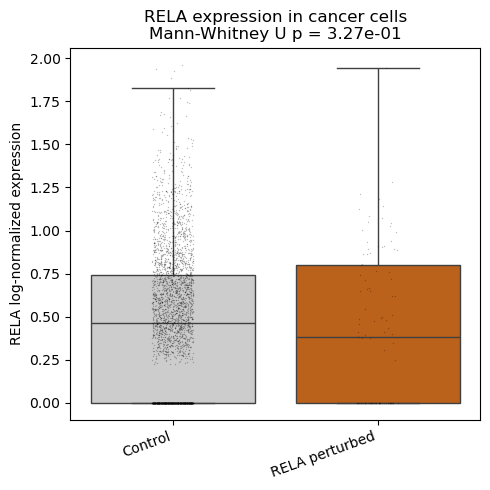

Expression source: adata.layers['lognorm']
Expression scale: lognorm
Cell type: cancer
Gene: TBK1
Perturbed cells: 16
Control cells: 3452

Summary:
            group  n_cells      mean    median  fraction_zero  \
0         Control     3452  0.533266  0.564302       0.298667   
1  TBK1 perturbed       16  0.608947  0.623114       0.125000   

   mannwhitneyu_pvalue  
0             0.483036  
1             0.483036  


/home/edizcan/SPERB/src/utils/single_cell.py:743: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


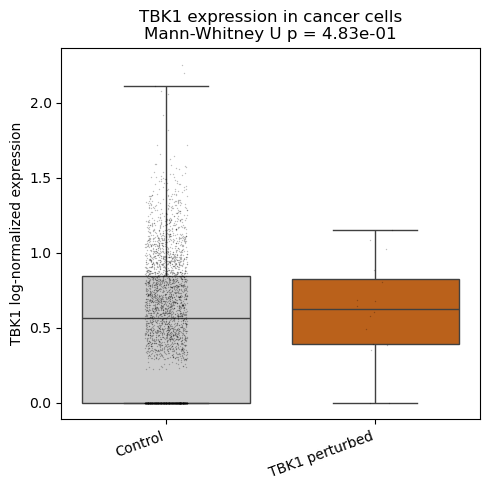

In [30]:
genes = ['CD14', 'IKBKB', 'IRF3', 'IRF5', 'JUN', 'MAP2K1', 'NFKB1', 'NFKBIA', 'PIK3CA', 'RELA', 'TBK1']

for gene in genes:
    fig, ax, plot_df, summary_df = plot_perturbation_effect(
        adata,
        cell_type="cancer",
        gene=gene,
        perturbation_col="perturbation",
        perturbation="gene",
        celltype_col="celltype2",
        control="Control",
        layer="lognorm",
        expression_scale="lognorm",
        point_size=1,
    )

Gene: CD14
Expression source: adata.layers['lognorm']  (lognorm)
Perturbed label: 'CD14'   Control label: 'Control'  (cell-type matched)
Candidate cell types: 3   tested: 2   (thresholds: >= 3 perturbed, >= 10 control)
Excluded (too few cells):
cell_type  n_perturbed  n_control
    other            1         61

Per-cell-type results:
cell_type  n_perturbed  n_control  mean_perturbed  mean_control   log2fc  pvalue  qvalue
  T cells           15        737          0.0000        0.0492 -26.0239  0.2188  0.4377
   cancer           16       3452          0.0142        0.0483  -2.0550  0.5689  0.5689
Gene: IKBKB
Expression source: adata.layers['lognorm']  (lognorm)
Perturbed label: 'IKBKB'   Control label: 'Control'  (cell-type matched)
Candidate cell types: 3   tested: 3   (thresholds: >= 3 perturbed, >= 10 control)

Per-cell-type results:
cell_type  n_perturbed  n_control  mean_perturbed  mean_control  log2fc  pvalue  qvalue
    other            4         61          0.4876        0.2928

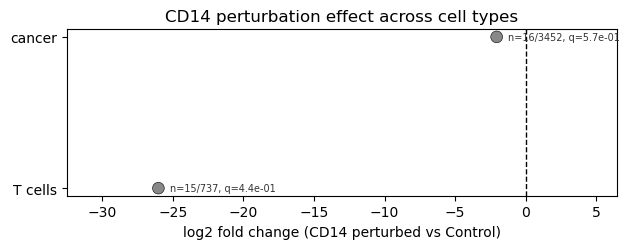

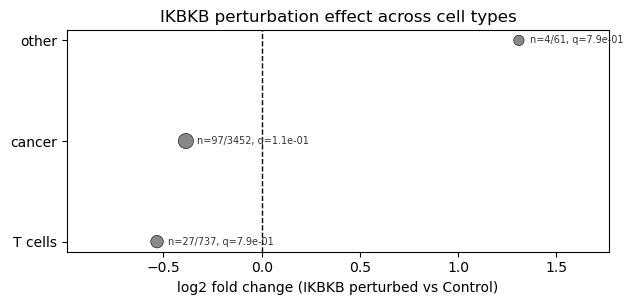

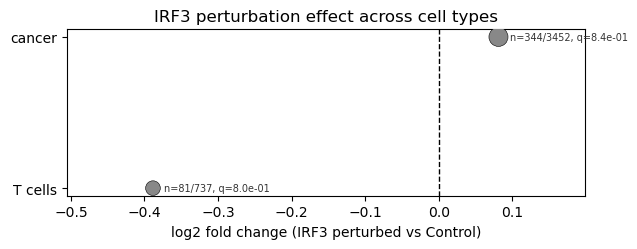

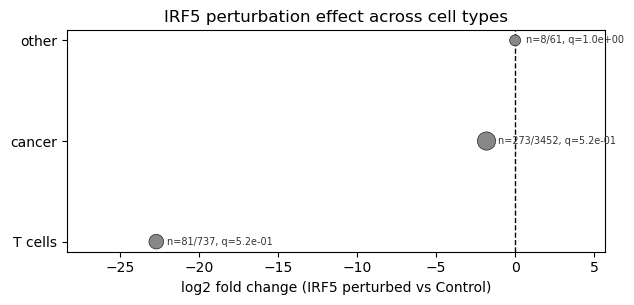

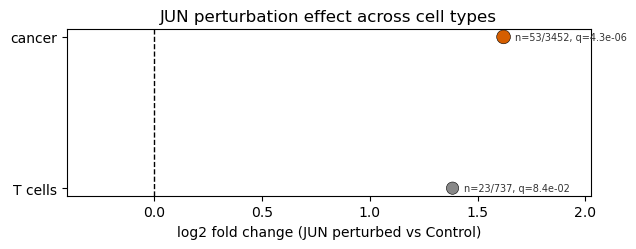

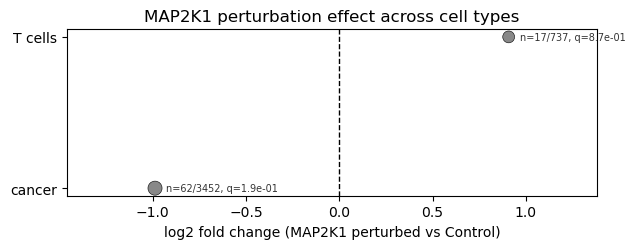

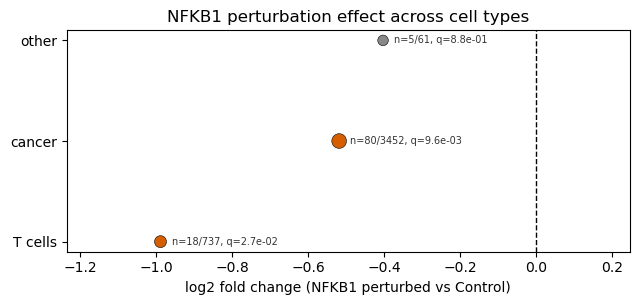

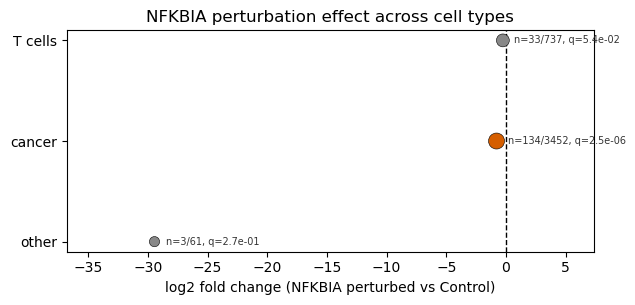

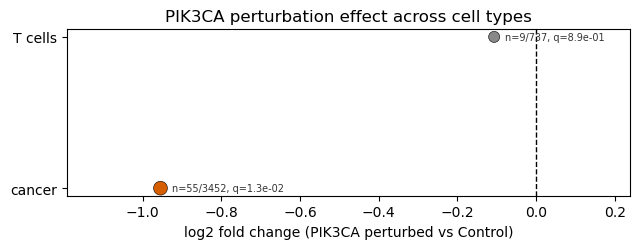

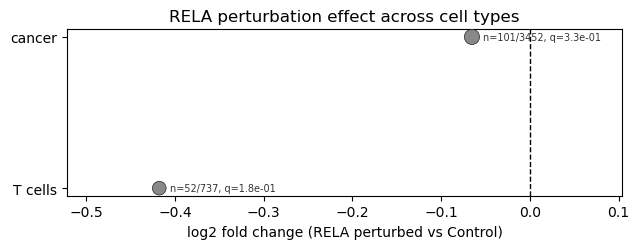

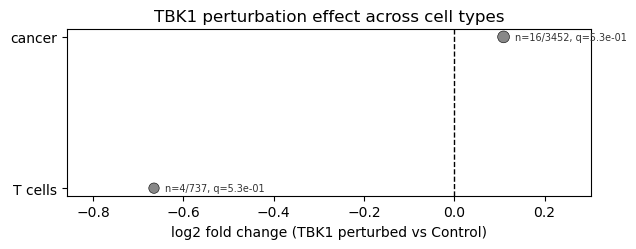

In [31]:
genes = ['CD14', 'IKBKB', 'IRF3', 'IRF5', 'JUN', 'MAP2K1', 'NFKB1', 'NFKBIA', 'PIK3CA', 'RELA', 'TBK1']

for gene in genes:
    fig, res = plot_perturbation_effect_by_celltype(
        adata,
        gene=gene,  
        celltype_col="celltype2",
        perturbation_col="perturbation",
        perturbation="gene",
        control="Control",
        layer="lognorm",
        plot_kind="forest",
        sort_by="effect",
    )

Number of unique perturbation labels: 157
Number of genes in adata: 500
Number of direct perturbation-gene matches: 11
Selected cell type: cancer
Control cells: 3452
Expression source: adata.layers['lognorm']
Expression scale: lognorm
Number of matched perturbation genes in this cell type: 11
Plotting top 11 perturbation genes:
perturbation
IRF3      344
IRF5      273
NFKBIA    134
RELA      101
IKBKB      97
NFKB1      80
MAP2K1     62
PIK3CA     55
JUN        53
CD14       16
TBK1       16
Name: count, dtype: int64


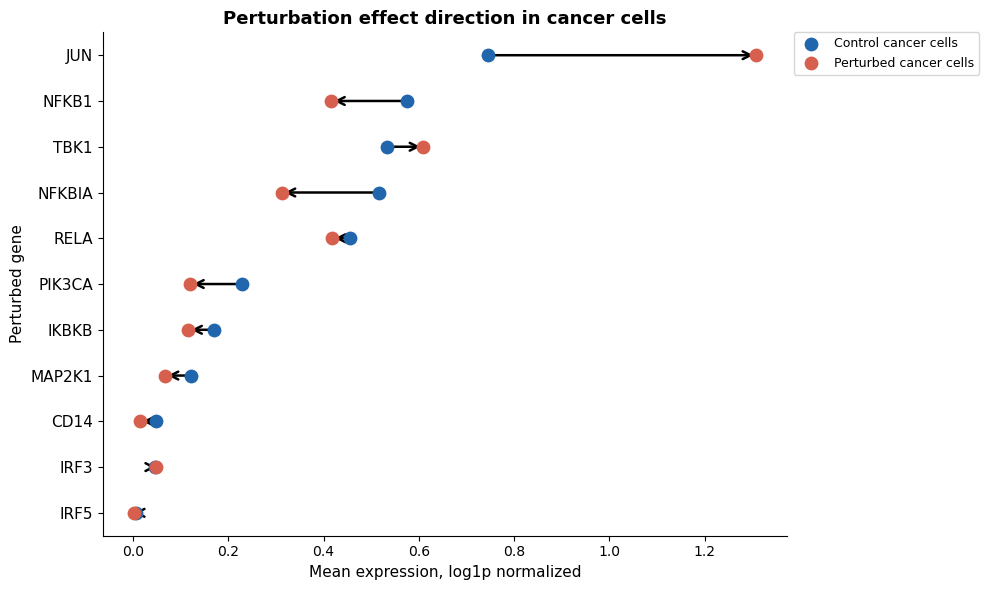

Number of unique perturbation labels: 157
Number of genes in adata: 500
Number of direct perturbation-gene matches: 11
Selected cell type: T cells
Control cells: 737
Expression source: adata.layers['lognorm']
Expression scale: lognorm
Number of matched perturbation genes in this cell type: 11
Plotting top 11 perturbation genes:
perturbation
IRF3      81
IRF5      81
RELA      52
NFKBIA    33
IKBKB     27
JUN       23
NFKB1     18
MAP2K1    17
CD14      15
PIK3CA     9
TBK1       4
Name: count, dtype: int64


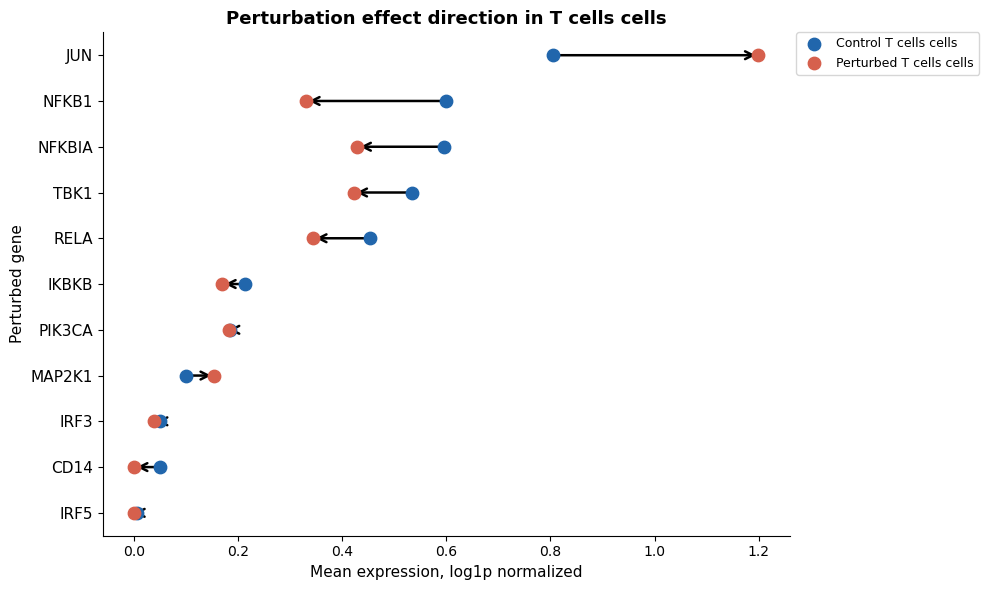

In [32]:
for ct in ["cancer", "T cells"]:
    fig, ax, results_df = plot_perturbation_mean_effect(
        adata,
        cell_type=ct,
        n_perturbation=11,
        celltype_col="celltype2",
        perturbation_col="perturbation",
        control_label="Control",
    )

In [33]:
# as you can see there are some T cells with perturbation. During training we need to remove them as such perturbation might interfere with propagated perturbation effect from perturbed cancer cells
is_tcell = adata.obs["celltype2"] == "T cells"
is_control = adata.obs["perturbation"] == "Control"

keep = ~is_tcell | is_control 
adata_f = adata[keep].copy()

print(f"removed {(~keep).sum()} perturbed T cells")
print(adata_f.obs.groupby("celltype2", observed=True)["n_perturb"].agg(
    n="size", n_perturbed=lambda s: (s > 0).sum()
))

removed 38513 perturbed T cells
                n  n_perturbed
celltype2                     
T cells       737          737
cancer     110912         7496
other        4256          146



Building spatial graph for radius = 75 µm
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


r=75 µm | median neighbors: 63.0 | mean: 60.8 | zero-neighbor cells: 10


100%|██████████| 1000/1000 [00:11<00:00, 87.67/s]


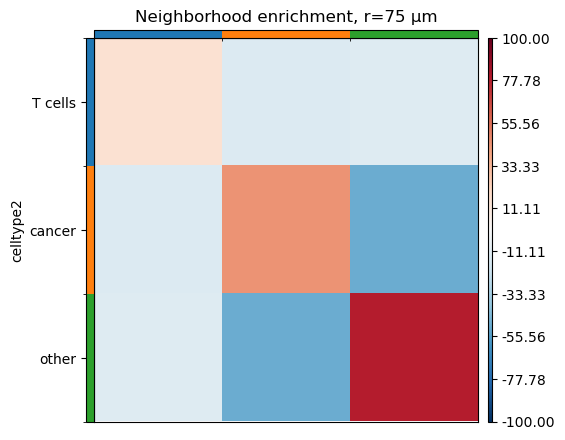

In [34]:
adata_qc, neighbor_stats, enrichment_results = plot_neighbor_heatmap(
    adata_f,
    distance=75,
    scale_factor= 5.4 / 50,
    cluster_key="celltype2",
)

In [40]:
adata_f.write_h5ad("/home/edizcan/sds-hd/sd22b002/guest/zeynep_thesis/perturb_fish/tumors/pfish_filtered_test.h5ad")

In [2]:
adata_f = sc.read_h5ad("/home/edizcan/sds-hd/sd22b002/guest/zeynep_thesis/perturb_fish/tumors/pfish_filtered_test.h5ad")
adata_f

AnnData object with n_obs × n_vars = 115905 × 500
    obs: 'cell_index', 'area', 'total_counts', 'celltype', 'celltype2', 'perturbation', 'n_perturb', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'celltype2_colors', 'celltype2_nhood_enrichment', 'spatial_neighbors'
    obsm: 'spatial', 'spatial_um'
    layers: 'counts', 'lognorm'
    obsp: 'spatial_connectivities', 'spatial_distances'

CD14: 16 perturbed cancer cells
IKBKB: 97 perturbed cancer cells
IRF3: 344 perturbed cancer cells
IRF5: 273 perturbed cancer cells
JUN: 53 perturbed cancer cells
MAP2K1: 62 perturbed cancer cells
NFKB1: 80 perturbed cancer cells
NFKBIA: 134 perturbed cancer cells
PIK3CA: 55 perturbed cancer cells
RELA: 101 perturbed cancer cells
TBK1: 16 perturbed cancer cells


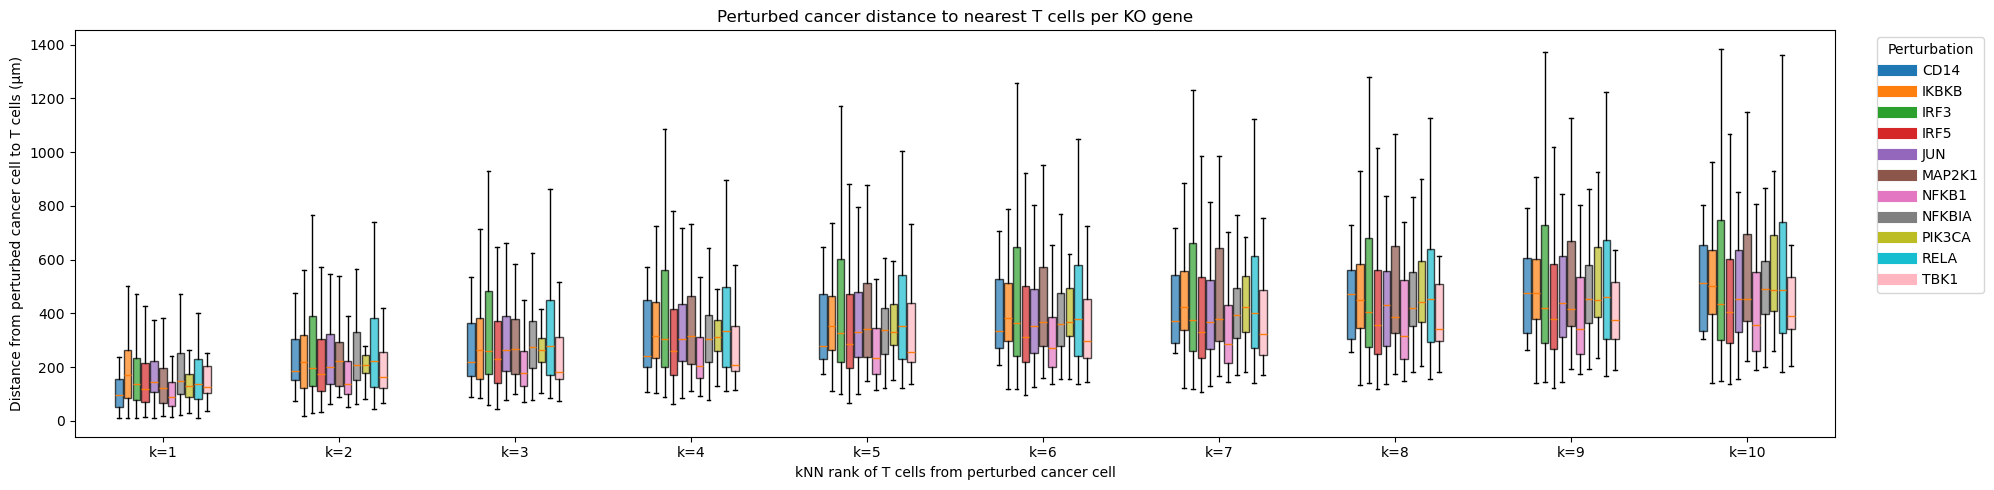

In [3]:
genes = ['CD14', 'IKBKB', 'IRF3', 'IRF5', 'JUN', 'MAP2K1', 'NFKB1', 'NFKBIA', 'PIK3CA', 'RELA', 'TBK1']

long_df, fig, ax = plot_knn_neighs(
    adata_f, k=10, genes=genes,
    perturbed_celltype="cancer", analyse_celltype="T cells",
    figsize=(20,5)
)

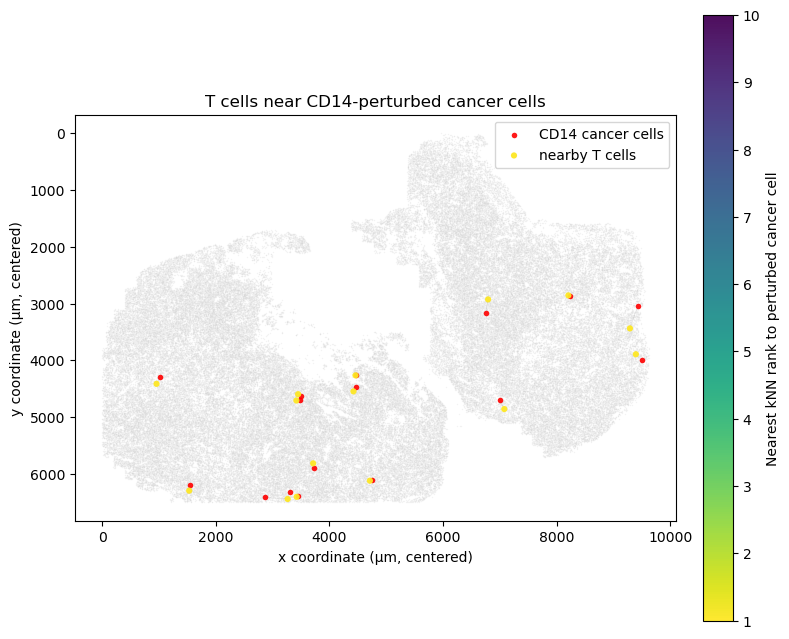

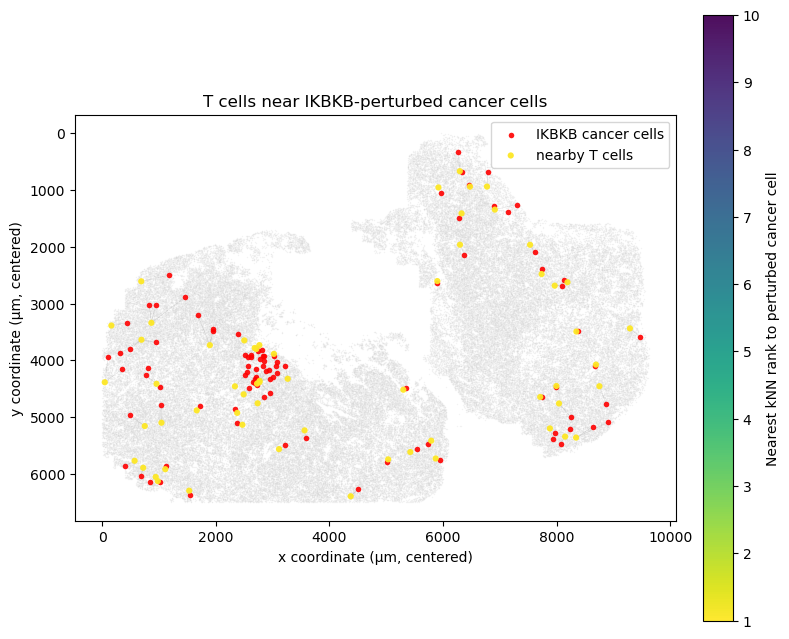

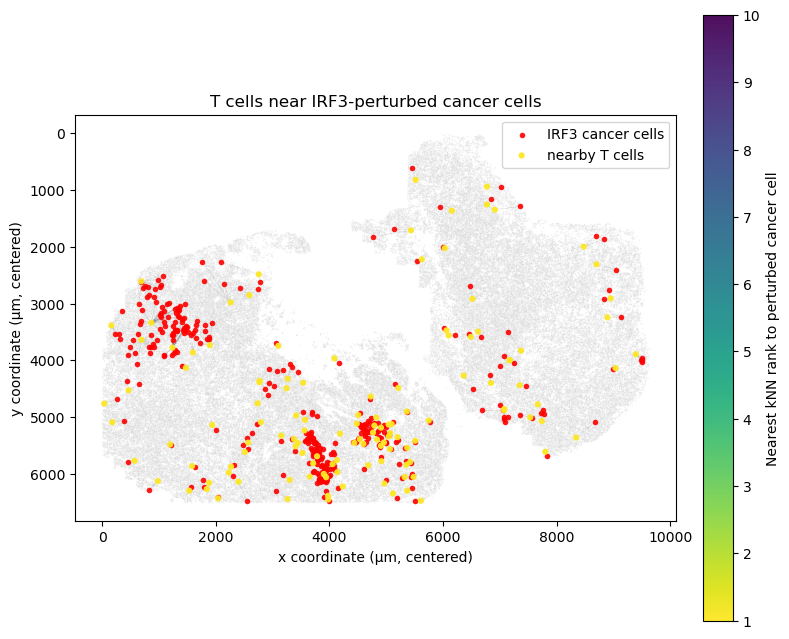

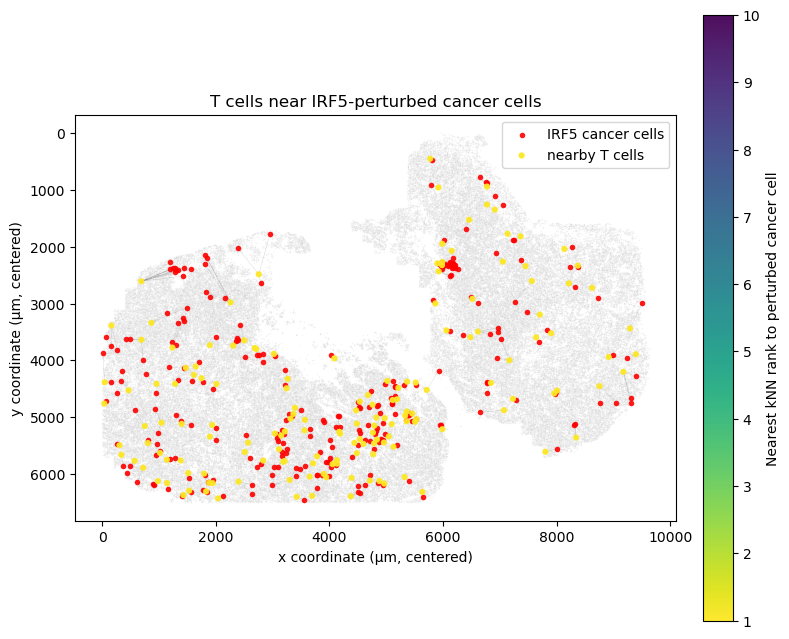

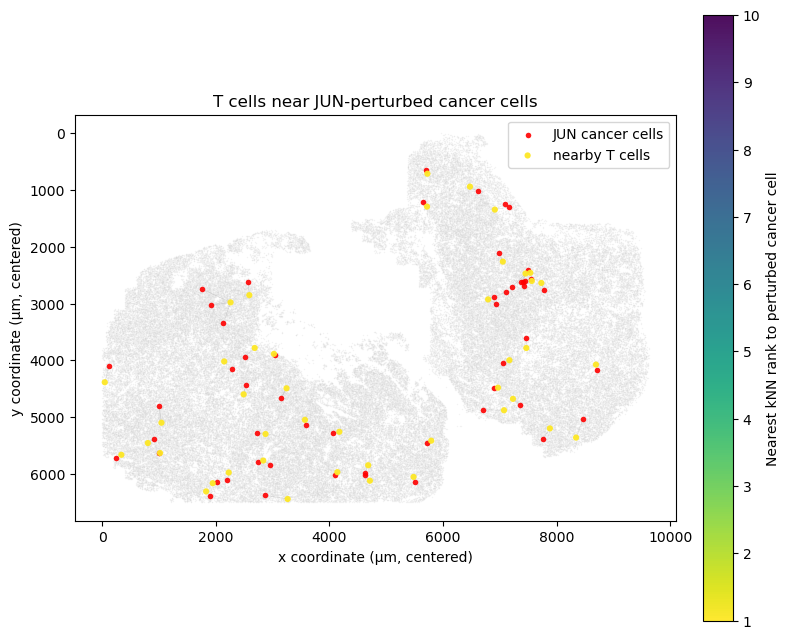

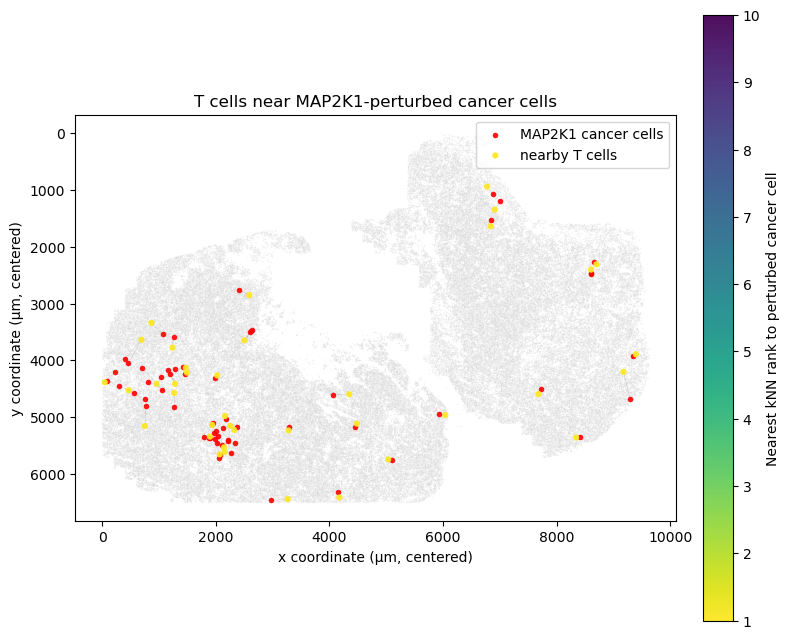

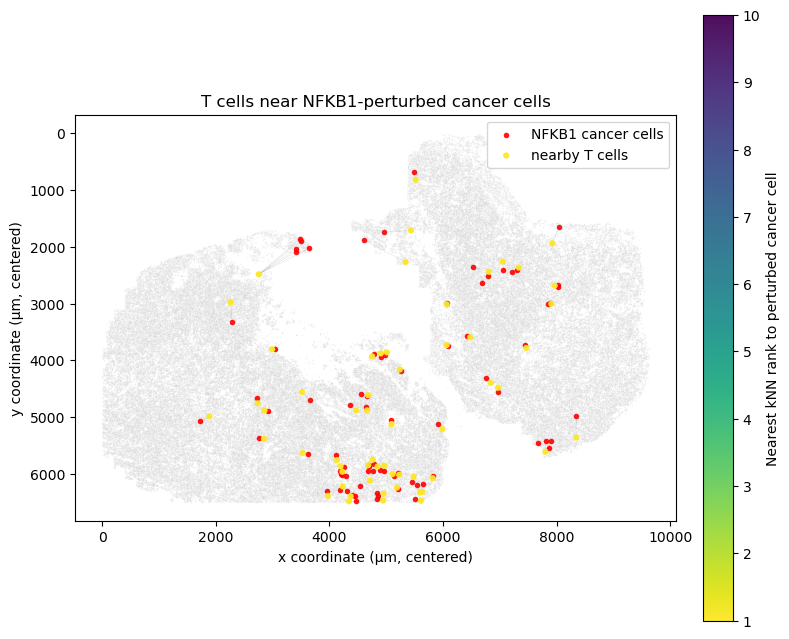

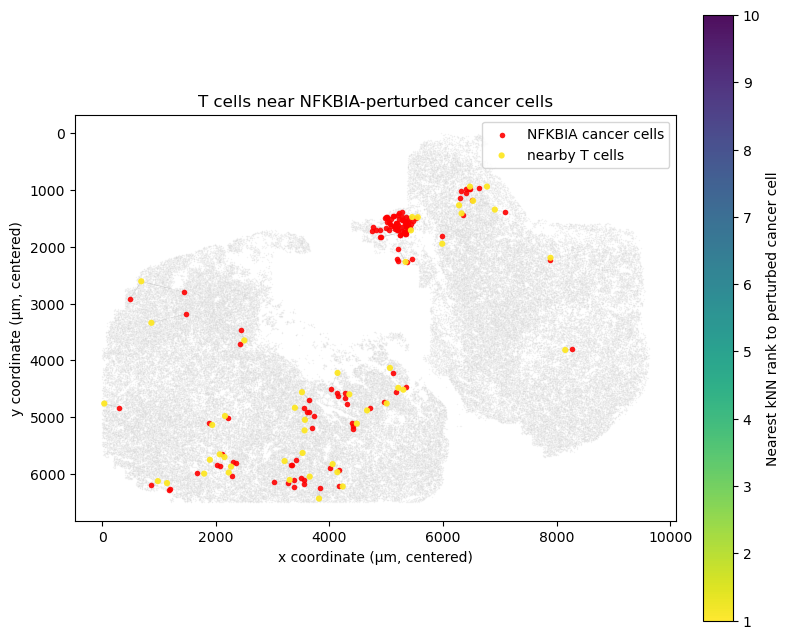

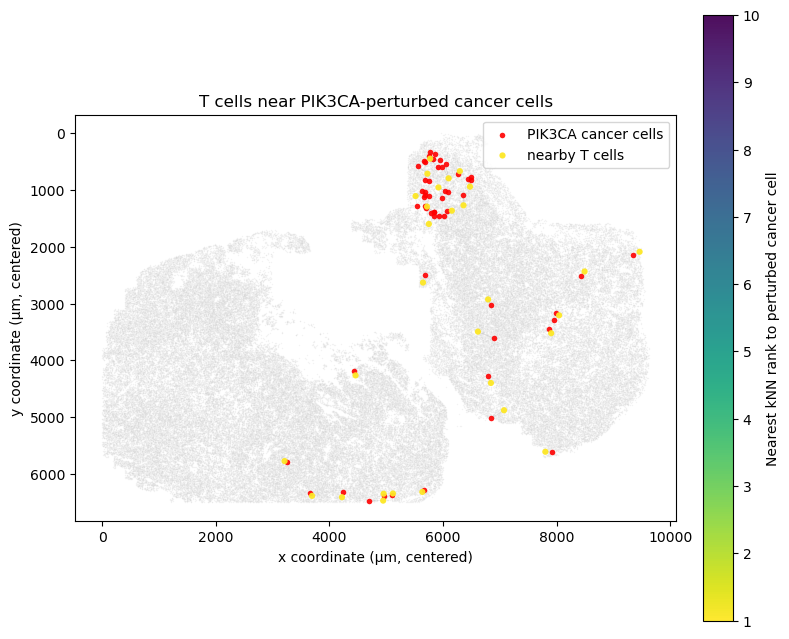

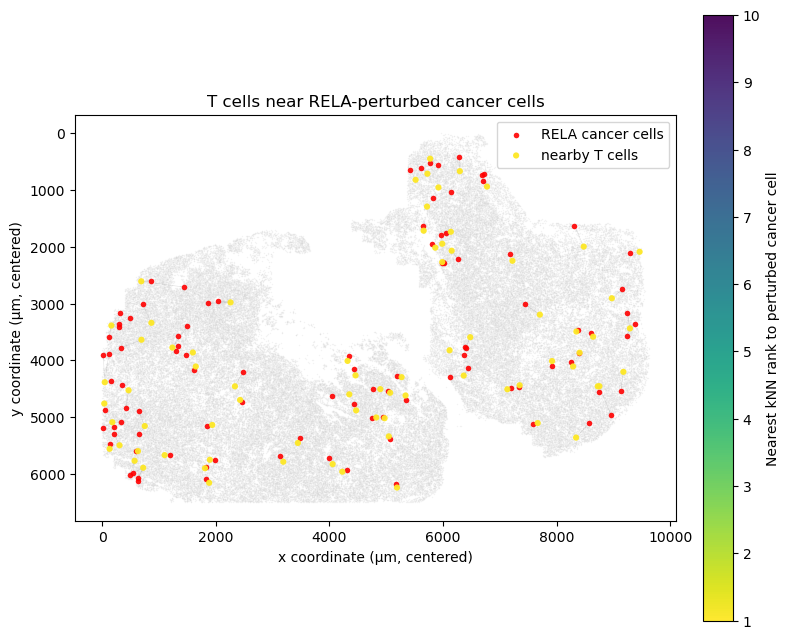

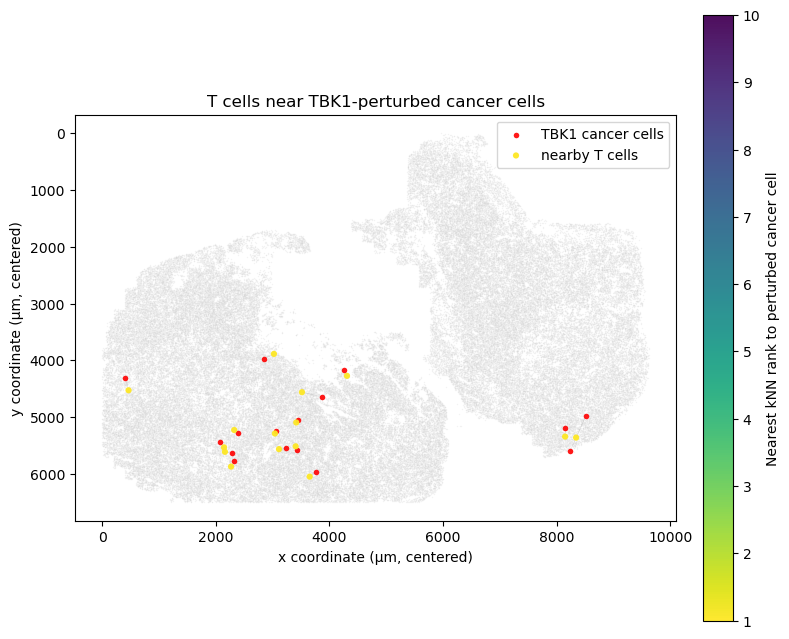

In [5]:
genes = ['CD14', 'IKBKB', 'IRF3', 'IRF5', 'JUN', 'MAP2K1', 'NFKB1', 'NFKBIA', 'PIK3CA', 'RELA', 'TBK1']

# Show only neighs with knn = 1
visualize_knn_neighs(adata_f, long_df, genes=genes, k=10, rank_filter=1)

As you can see some T cells with knn=1 are actually far away from perturbed cancer cells

T cells: 737 unperturbed candidates (excluded 0 perturbed).
CD14: 16 perturbed cancer cells
IKBKB: 97 perturbed cancer cells
IRF3: 344 perturbed cancer cells
IRF5: 273 perturbed cancer cells
JUN: 53 perturbed cancer cells
MAP2K1: 62 perturbed cancer cells
NFKB1: 80 perturbed cancer cells
NFKBIA: 134 perturbed cancer cells
PIK3CA: 55 perturbed cancer cells
RELA: 101 perturbed cancer cells
TBK1: 16 perturbed cancer cells

Wrote adata.obs['tcell_near_perturbed']: 241 of 737 candidate T cells flagged as within 75 µm.


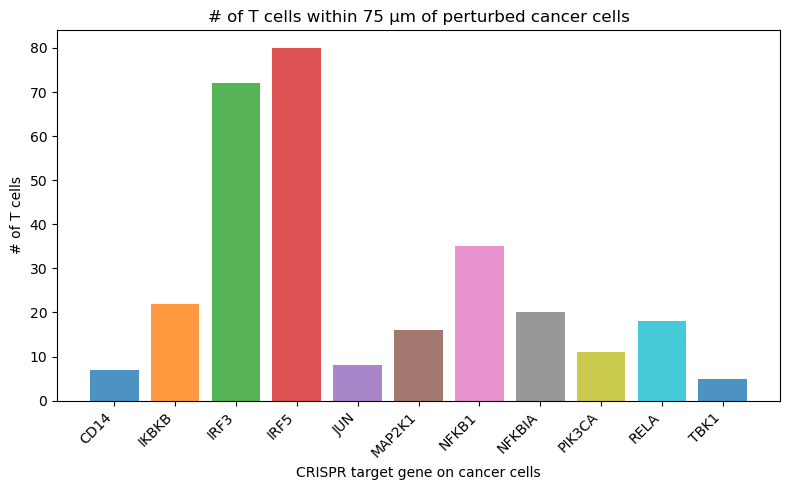

In [6]:
genes = ['CD14', 'IKBKB', 'IRF3', 'IRF5', 'JUN', 'MAP2K1', 'NFKB1', 'NFKBIA', 'PIK3CA', 'RELA', 'TBK1']

radius_df, summary = flag_neighs_near_perturbed(
    adata_f, genes=genes, radius_um=75, um_per_pixel=5.4 / 50,
    perturbed_celltype="cancer", analyse_celltype="T cells"
)

In [7]:
adata_f.obs["tcell_near_perturbed"].value_counts()

tcell_near_perturbed
False    115664
True        241
Name: count, dtype: int64

In [8]:
adata_f.write_h5ad("/home/edizcan/sds-hd/sd22b002/guest/zeynep_thesis/perturb_fish/tumors/pfish_xenograf_final.h5ad")

In [2]:
adata = sc.read_h5ad("/home/edizcan/sds-hd/sd22b002/guest/zeynep_thesis/perturb_fish/tumors/pfish_xenograf_final.h5ad")
adata

AnnData object with n_obs × n_vars = 115905 × 500
    obs: 'cell_index', 'area', 'total_counts', 'celltype', 'celltype2', 'perturbation', 'n_perturb', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'tcell_near_perturbed', 'tcell_near_perturbed_dist_um'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'celltype2_colors', 'celltype2_nhood_enrichment', 'spatial_neighbors'
    obsm: 'spatial', 'spatial_um'
    layers: 'counts', 'lognorm'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [3]:
adata = adata[adata.obs["n_perturb"] < 2].copy()
adata

AnnData object with n_obs × n_vars = 115638 × 500
    obs: 'cell_index', 'area', 'total_counts', 'celltype', 'celltype2', 'perturbation', 'n_perturb', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'tcell_near_perturbed', 'tcell_near_perturbed_dist_um'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'celltype2_colors', 'celltype2_nhood_enrichment', 'spatial_neighbors'
    obsm: 'spatial', 'spatial_um'
    layers: 'counts', 'lognorm'
    obsp: 'spatial_connectivities', 'spatial_distances'

## Run CausalInteractionBench pairs

IKBKB (produces) maps to production categories: ['cytokine']
94 candidate response genes in panel
T cells near perturbed (radius=75.0um): 22 cells
T cells near control (radius=75.0um):   591 cells
IKBKB (responds_to) maps to response categories: ['cytokine', 'hormone', 'peptide', 'peptide_hormone', 'tumor_necrosis_factor']
138 candidate production genes in panel
T cells near perturbed (radius=75.0um): 22 cells
T cells near control (radius=75.0um):   591 cells


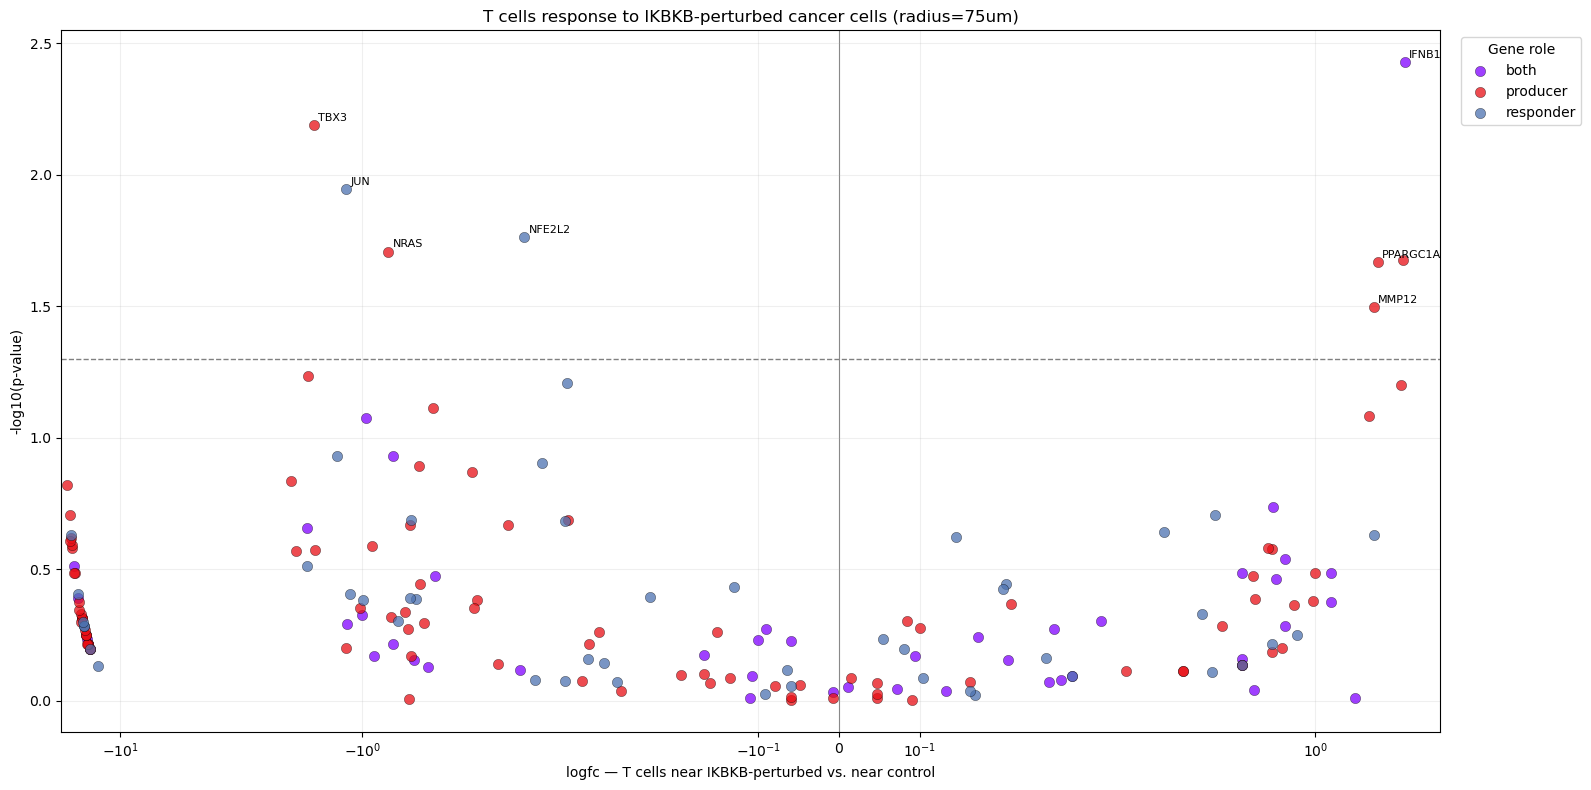

In [5]:
combined, result_forward, result_reverse = plot_causal_volcano(
    adata=adata,
    pairs_dir="/home/edizcan/sds-hd/sd22b002/guest/zeynep_thesis/CausalInteractionBench/pairs",
    perturbation_gene="IKBKB",
    perturbed_celltype="cancer",
    neighbor_celltype="T cells",
    celltype_col="celltype2",
    perturbation_col="perturbation",
    spatial_key="spatial_um",
    radius_um=75.0,
    control_label="Control",
    layer="counts",
    pseudocount=1e-6,
    exclusive=True,
    min_pct=0.1,    
    pval_threshold=0.05,
    logfc_clip=None,
    symlog_linthresh=0.5,
    symlog_linscale=1.5,
    figsize=(16, 8),
    savepath=None,  
)

In [6]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

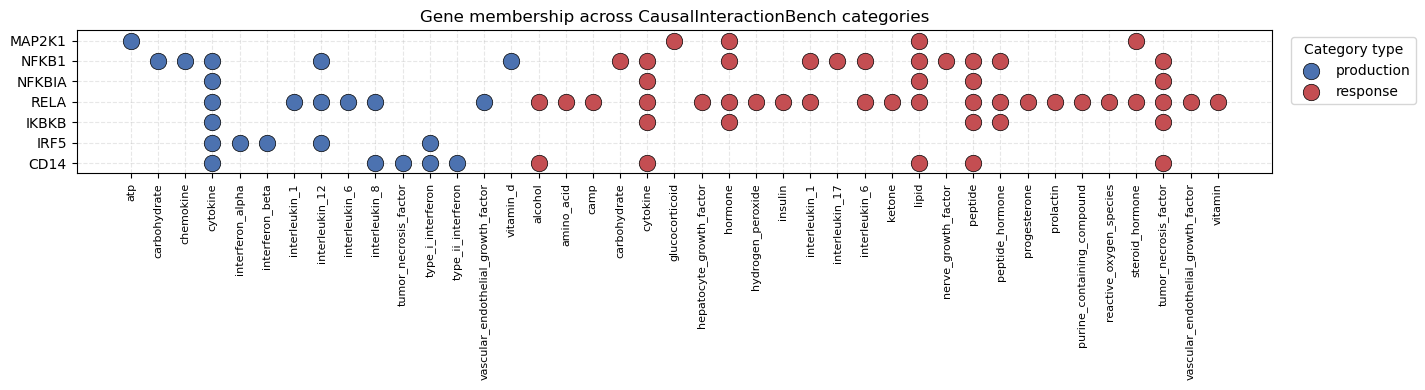

In [7]:
pairs_dir = os.path.expanduser("/home/edizcan/sds-hd/sd22b002/guest/zeynep_thesis/CausalInteractionBench/pairs")
csv_files = sorted(glob.glob(os.path.join(pairs_dir, "*.csv")))

genes_of_interest = ["CD14", "IRF5", "IKBKB", "RELA", "NFKBIA", "NFKB1", "MAP2K1"]
genes_upper = {g.upper() for g in genes_of_interest}

gene_to_categories = defaultdict(set)

for fpath in csv_files:
    fname = os.path.basename(fpath).replace(".csv", "")
    df = pd.read_csv(fpath, header=None)
    file_genes = df[0].astype(str).str.strip()

    if file_genes.iloc[0].upper() in {"GENE", "GENES", "SYMBOL", "GENE_SYMBOL"}:
        file_genes = file_genes.iloc[1:]

    file_genes_upper = set(file_genes.str.upper())
    hits = genes_upper & file_genes_upper
    for g in hits:
        gene_to_categories[g].add(fname)

# Only categories with at least one hit
all_categories = sorted(set.union(*gene_to_categories.values())) if gene_to_categories else []

# Build long-form data for scatter: (gene, category, group)
records = []
for g in genes_of_interest:
    for cat in gene_to_categories.get(g.upper(), []):
        group = "production" if cat.startswith("production_") else "response"
        label = cat.replace("production_", "").replace("response_", "")
        records.append({"gene": g, "category": cat, "label": label, "group": group})

df_long = pd.DataFrame(records)

if df_long.empty:
    print("No matches found for any gene.")
else:
    # Order categories (x-axis) and genes (y-axis)
    cat_order = sorted(df_long["category"].unique())
    gene_order = genes_of_interest  # keep original input order

    cat_to_x = {c: i for i, c in enumerate(cat_order)}
    gene_to_y = {g: i for i, g in enumerate(gene_order)}

    colors = {"production": "#4C72B0", "response": "#C44E52"}

    fig, ax = plt.subplots(figsize=(max(8, len(cat_order) * 0.35), max(4, len(gene_order) * 0.5)))

    for group in ["production", "response"]:
        sub = df_long[df_long["group"] == group]
        xs = sub["category"].map(cat_to_x)
        ys = sub["gene"].map(gene_to_y)
        ax.scatter(xs, ys, s=140, color=colors[group], label=group, edgecolor="black", linewidth=0.5, zorder=3)

    ax.set_xticks(range(len(cat_order)))
    ax.set_xticklabels([c.replace("production_", "").replace("response_", "") for c in cat_order],
                        rotation=90, fontsize=8)
    ax.set_yticks(range(len(gene_order)))
    ax.set_yticklabels(gene_order, fontsize=10)
    ax.set_ylim(-0.5, len(gene_order) - 0.5)
    ax.grid(axis="both", linestyle="--", alpha=0.3, zorder=0)
    ax.set_title("Gene membership across CausalInteractionBench categories")
    ax.legend(title="Category type", loc="upper left", bbox_to_anchor=(1.01, 1))

    plt.tight_layout()
    plt.savefig("gene_category_dotplot.png", dpi=150)
    plt.show()

## Run PROGENy Pathway Scoring

In [2]:
import decoupler as dc

In [3]:
adata = sc.read_h5ad("/home/edizcan/sds-hd/sd22b002/guest/zeynep_thesis/perturb_fish/tumors/pfish_xenograf_final.h5ad")
adata

AnnData object with n_obs × n_vars = 115905 × 500
    obs: 'cell_index', 'area', 'total_counts', 'celltype', 'celltype2', 'perturbation', 'n_perturb', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'tcell_near_perturbed', 'tcell_near_perturbed_dist_um'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'celltype2_colors', 'celltype2_nhood_enrichment', 'spatial_neighbors'
    obsm: 'spatial', 'spatial_um'
    layers: 'counts', 'lognorm'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [4]:
progeny = dc.op.progeny(organism="human") 
progeny

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
...,...,...,...,...
62416,p53,ENPP2,2.771405,4.993215e-02
62417,p53,ARRDC4,3.494328,4.996747e-02
62418,p53,MYO1B,-1.148057,4.997905e-02
62419,p53,CTSC,-1.784693,4.998864e-02


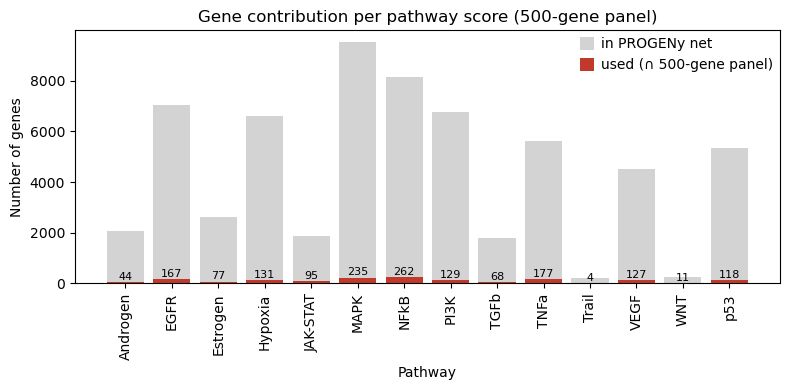

In [5]:
panel = set(adata.var_names)                       # 500-gene panel
used  = progeny[progeny["target"].isin(panel)].groupby("source")["target"].nunique()
total = progeny.groupby("source")["target"].nunique()   # full PROGENy footprint

order = ["Androgen","EGFR","Estrogen","Hypoxia","JAK-STAT","MAPK","NFkB",
         "PI3K","TGFb","TNFa","Trail","VEGF","WNT","p53"]

used  = used.reindex(order).fillna(0).astype(int)
total = total.reindex(order).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(order, total, color="lightgrey", label="in PROGENy net")
ax.bar(order, used,  color="#c0392b",  label=f"used (∩ {len(panel)}-gene panel)")
for i, v in enumerate(used):
    ax.text(i, v + 2, str(v), ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Pathway")
ax.set_ylabel("Number of genes")
ax.set_title(f"Gene contribution per pathway score ({len(panel)}-gene panel)")
ax.legend(frameon=False)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [5]:
# Run pathway activity inference using the full progeny network
dc.mt.ulm(data=adata, net=progeny)
adata


AnnData object with n_obs × n_vars = 115905 × 500
    obs: 'cell_index', 'area', 'total_counts', 'celltype', 'celltype2', 'perturbation', 'n_perturb', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'tcell_near_perturbed', 'tcell_near_perturbed_dist_um'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'celltype2_colors', 'celltype2_nhood_enrichment', 'spatial_neighbors'
    obsm: 'spatial', 'spatial_um', 'score_ulm', 'padj_ulm'
    layers: 'counts', 'lognorm'
    obsp: 'spatial_connectivities', 'spatial_distances'

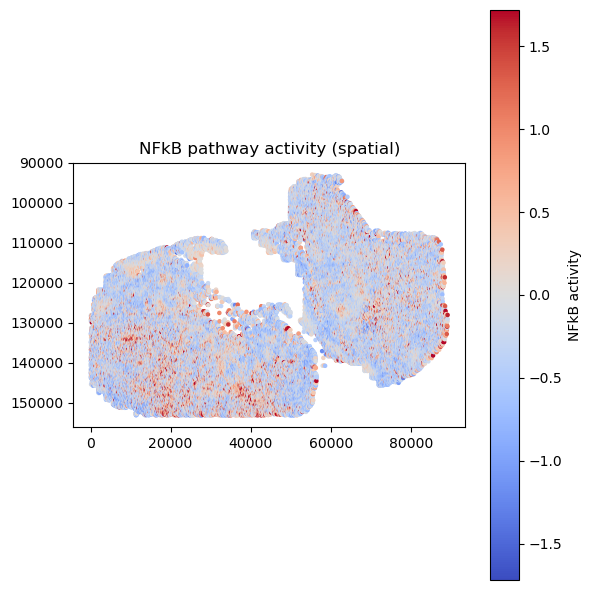

In [7]:
for pw in ['NFkB']:
    plot_pathway_spatial(adata, pw)
    plt.show()

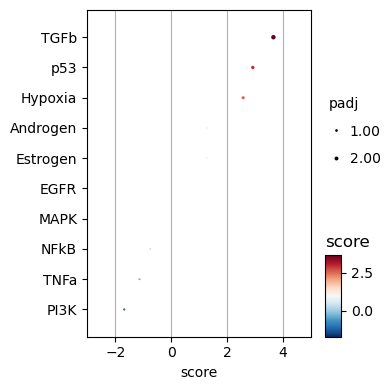

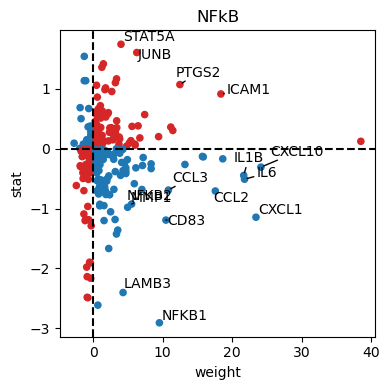

In [8]:
scores, padjs, deg = compute_group_pathway_stats(
    adata,
    groupby='perturbation',
    net=progeny,
    celltype_col='celltype2',
    celltype='cancer',
    perturbation_col='perturbation',
    perturbation=['NFKB1', 'Control'],
    groups=['NFKB1'],
    reference='Control',
    layer='lognorm',
)

plot_pathway_dotplot(scores, padjs, group='NFKB1')
plot_pathway_source_targets(deg, progeny, group='NFKB1', pathway='NFkB', top=15)